Can a LSA transformer learn to behave like gradient descent when solving linear regression tasks in context, even as the problem gets bigger?

### Scaling Study: Effect of (d, n) on LSA vs One-Step GD

We trained a 1-layer Linear Self-Attention (LSA) model to imitate one-step gradient descent on linear regression tasks, and varied the input dimension \(d\) and the number of in-context examples \(n\) as:

- \((d, n) = (5, 11)\)
- \((d, n) = (10, 21)\)
- \((d, n) = (20, 41)\)


In [15]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

In [16]:
class LinearTaskSampler:
    def __init__(self, d, n, batch_tasks, out_dim=1, x_range=1.0, device="cpu"):
        self.d, self.n, self.B = d, n, batch_tasks
        self.out_dim = out_dim
        self.x_range = x_range
        self.device = device

    def sample_batch(self):
        B, d, n = self.B, self.d, self.n
        W = torch.randn(B, self.out_dim, d, device=self.device)
        X = (2*self.x_range)*torch.rand(B, n, d, device=self.device) - self.x_range
        Y = torch.einsum("bnd, bod->bno", X, W)
        x_q = (2*self.x_range)*torch.rand(B, d, device=self.device) - self.x_range
        y_q = torch.einsum("bd, bod->bo", x_q, W)
        return X, Y, x_q, y_q, W

In [17]:
class LinearSelfAttention1L(nn.Module):
    def __init__(self, token_dim):
        super().__init__()
        D = token_dim
        self.W_Q = nn.Linear(D, D, bias=False)
        self.W_K = nn.Linear(D, D, bias=False)
        self.W_V = nn.Linear(D, D, bias=False)
        self.P   = nn.Linear(D, D, bias=False)

    def forward(self, tokens):
        Q = self.W_Q(tokens)
        K = self.W_K(tokens)
        V = self.W_V(tokens)
        att = torch.einsum("bid,bjd->bij", K, Q)
        val = torch.einsum("bij,bjd->bid", att, V)
        return tokens + self.P(val)


In [18]:
def build_tokens(X, Y, x_q, out_dim=1):
    B, n, d = X.shape
    y_q_init = torch.zeros(B, out_dim, device=X.device)
    ctx = torch.cat([X, Y], dim=-1)
    q = torch.cat([x_q, y_q_init], dim=-1).unsqueeze(1)
    return torch.cat([ctx, q], dim=1)

def readout(updated, out_dim=1):
    return updated[:, -1, -out_dim:]


In [19]:
def gd_one_step(X, Y, x_q, lr):
    B, n, d = X.shape
    delta = (lr/n) * (X * Y).sum(dim=1)
    return (delta * x_q).sum(dim=-1, keepdim=True)


In [20]:
configs = [
    (5,  11),
    (10, 21),
    (20, 41),
]

batch_tasks = 256
num_steps = 2000
gd_lr = 0.5

results = {}


In [21]:
def run_experiment(d, n):
    sampler = LinearTaskSampler(d=d, n=n, batch_tasks=batch_tasks, device=device)
    model = LinearSelfAttention1L(token_dim=d+1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    lsa_losses = []
    for step in range(1, num_steps+1):
        X, Y, x_q, y_q, _ = sampler.sample_batch()
        X, Y, x_q, y_q = X.to(device), Y.to(device), x_q.to(device), y_q.to(device)

        tokens = build_tokens(X, Y, x_q)
        out = model(tokens)
        y_lsa = readout(out)

        with torch.no_grad():
            y_gd = gd_one_step(X, Y, x_q, lr=gd_lr)

        loss = F.mse_loss(y_lsa, y_q)
        opt.zero_grad()
        loss.backward()
        opt.step()
        lsa_losses.append(loss.item())

    X, Y, x_q, y_q, _ = sampler.sample_batch()
    X, Y, x_q, y_q = X.to(device), Y.to(device), x_q.to(device), y_q.to(device)
    y_lsa = readout(model(build_tokens(X, Y, x_q)))
    y_gd = gd_one_step(X, Y, x_q, gd_lr)

    mse_lsa = F.mse_loss(y_lsa, y_q).item()
    mse_gd  = F.mse_loss(y_gd,  y_q).item()
    cos_sim = torch.nn.functional.cosine_similarity(y_lsa, y_gd).mean().item()

    return mse_lsa, mse_gd, cos_sim, lsa_losses


In [22]:
for d, n in configs:
    mse_lsa, mse_gd, cos_sim, losses = run_experiment(d, n)
    results[(d,n)] = {
        "mse_lsa": mse_lsa,
        "mse_gd": mse_gd,
        "cos": cos_sim,
        "final_loss": losses[-1],
    }
    print((d,n), results[(d,n)])

(5, 11) {'mse_lsa': 0.5501484274864197, 'mse_gd': 1.308485984802246, 'cos': 0.9921875, 'final_loss': 0.426196426153183}
(10, 21) {'mse_lsa': 1.0581542253494263, 'mse_gd': 2.4751639366149902, 'cos': 0.953125, 'final_loss': 0.9370170831680298}
(20, 41) {'mse_lsa': 2.4933879375457764, 'mse_gd': 4.380040168762207, 'cos': 0.8828125, 'final_loss': 2.2772607803344727}


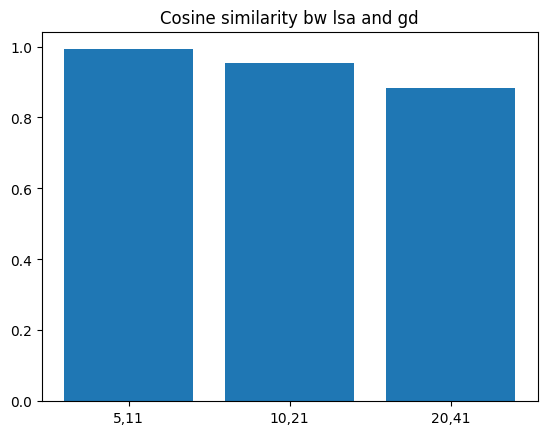

In [23]:
labels = [f"{d},{n}" for d,n in results.keys()]
cos_vals = [results[k]["cos"] for k in results]
plt.bar(labels, cos_vals)
plt.title("Cosine similarity bw lsa and gd")
plt.show()

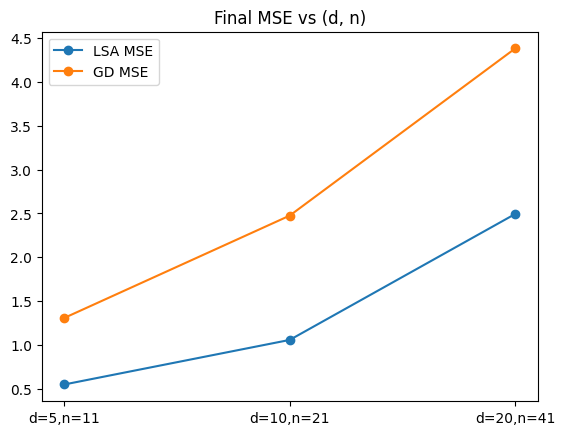

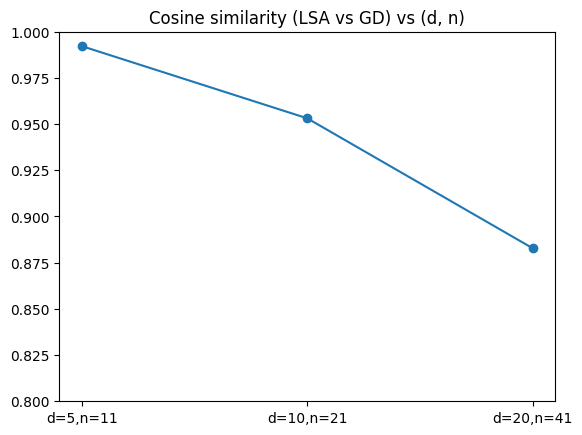

In [24]:
labels = [f"d={d},n={n}" for d,n in results.keys()]
mse_lsa = [results[k]["mse_lsa"] for k in results]
mse_gd  = [results[k]["mse_gd"] for k in results]
cos_vals = [results[k]["cos"] for k in results]

plt.figure()
plt.plot(labels, mse_lsa, marker="o", label="LSA MSE")
plt.plot(labels, mse_gd, marker="o", label="GD MSE")
plt.legend()
plt.title("Final MSE vs (d, n)")
plt.show()

plt.figure()
plt.plot(labels, cos_vals, marker="o")
plt.title("Cosine similarity (LSA vs GD) vs (d, n)")
plt.ylim(0.8, 1.0)
plt.show()


We observe that the LSA model consistently achieves lower MSE than the one-step GD baseline across all (d, n) configurations, suggesting that it learns an update rule that is at least as effective as fixed-step gradient descent and often slightly better 

Cosine similarity between LSA and GD predictions remains very strong (0.99 to 0.88) even as d increases, indicating that the model continues to perform GD-like inference in higher dimensions, though with reduced alignment

These results are relevant because they provide evidence that in-context learning can scale beyond very small tasks, and that self-attention layers can learn a reusable optimization procedure rather than memorizing task-specific mappings. This supports the broader hypothesis that transformers may internally implement approximate gradient descent when performing in-context learning